# Assignment 1: BigMart Sales Prediction using Linear Regression

## Objective and Business Context
BigMart is a retail chain with multiple store outlets across different cities. The objective of this assignment is to apply Linear Regression to predict product sales (`Item_Outlet_Sales`) using historical product and store characteristics. 

This notebook provides a complete, reproducible, and leak-free machine learning workflow structured strictly around the **16 Assignment Tasks**:
1. **Load Dataset**: Read train/test datasets and display the first 10 records.
2. **Dataset Structure**: Report row count, column count, and feature data types.
3. **Missing Value Audit**: Detect and quantify missing values and zero-visibility anomalies.
4. **Data Cleaning**: Standardize categories, convert zero visibility to missing, and engineer domain features.
5. **Variable Classification**: Separate predictor variables ($X$) and target ($y$) into numerical and categorical sets.
6. **Numerical EDA**: Examine distributions, skewness, and summary statistics of numerical variables.
7. **Target Relationships**: Analyze how product and outlet characteristics relate to `Item_Outlet_Sales`.
8. **Correlation Analysis**: Visualize numerical feature correlations via an annotated heatmap.
9. **Pipeline Preprocessing**: Set up `ColumnTransformer` with `SimpleImputer`, `StandardScaler`, and `OneHotEncoder(handle_unknown="ignore")`.
10. **Train-Test Split**: Partition labeled training data into training (80%) and validation (20%) sets.
11. **Feature/Target Definition**: Explicitly state $X$ predictors and $y$ target.
12. **Model Training**: Fit a `LinearRegression` pipeline strictly on training data.
13. **Sales Prediction**: Predict validation sales and generate official predictions for `test.csv` after retraining on 100% of labeled data.
14. **Model Evaluation & Residuals**: Evaluate performance using $R^2$, MAE, MSE, RMSE, and diagnose linear model assumptions with residual plots.
15. **Coefficient Interpretation**: Interpret linear regression coefficients without calling them "feature importance" or using causal language.
16. **Key Insights & Business Summary**: Summarize grounded numerical insights and strategic business recommendations.

## 1. Import Libraries and Configuration

In [6]:
# 1. Import required libraries and configure environment
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# To ignore non-critical warnings
warnings.filterwarnings("ignore")

# Configure visualization style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# Data Sources
RANDOM_STATE = 42
TRAIN_URL = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_train.csv"
TEST_URL = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv"
TARGET = "Item_Outlet_Sales"
DATASET_BASE_YEAR = 2013

print("Libraries successfully imported and configuration initialized.")

Libraries successfully imported and configuration initialized.


## Task 1: Load Dataset and Display First 10 Records

Load the labeled training dataset and test dataset from the assignment URLs, then display the first 10 records of the training set.

In [7]:
# Task 1: Load datasets and display the first 10 records
train_df = pd.read_csv(TRAIN_URL)
test_df = pd.read_csv(TEST_URL)

print(f"Training dataset shape: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Test dataset shape:     {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")

print("\nFirst 10 records of BigMart Training Dataset:")
display(train_df.head(10))

Training dataset shape: 8,523 rows, 12 columns
Test dataset shape:     5,681 rows, 11 columns

First 10 records of BigMart Training Dataset:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


## Task 2: Dataset Characteristics: Rows, Columns, and Data Types

Identify the number of rows, columns, and the data type of each feature in the BigMart dataset.

In [8]:
# Task 2: Display dataset structure and column data types
print(f"Total Rows:    {train_df.shape[0]:,}")
print(f"Total Columns: {train_df.shape[1]}")

data_types_df = pd.DataFrame({
    "Column_Name": train_df.columns,
    "Data_Type": train_df.dtypes.values,
    "Non_Null_Count": train_df.notna().sum().values
}).reset_index(drop=True)

display(data_types_df)

Total Rows:    8,523
Total Columns: 12


,Column_Name,Data_Type,Non_Null_Count
0,Item_Identifier,str,8523
1,Item_Weight,float64,7060
2,Item_Fat_Content,str,8523
3,Item_Visibility,float64,8523
4,Item_Type,str,8523
5,Item_MRP,float64,8523
6,Outlet_Identifier,str,8523
7,Outlet_Establishment_Year,int64,8523
8,Outlet_Size,str,6113
9,Outlet_Location_Type,str,8523


## Task 3: Detect and Report Missing Values

Detect missing values present in the dataset and report count and percentage for both training and test sets.

In [9]:
# Task 3: Missing value audit for Train and Test sets
def generate_missing_report(df, name="Dataset"):
    missing_count = df.isna().sum()
    missing_percent = (100 * missing_count / len(df)).round(2)
    report = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage (%)": missing_percent
    })
    return report[report["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

print("Missing values in Training Dataset:")
display(generate_missing_report(train_df, "Train"))

print("\nMissing values in Official Test Dataset:")
display(generate_missing_report(test_df, "Test"))

# Audit zero-visibility anomaly (physically impossible display visibility)
train_zeros = (train_df["Item_Visibility"] == 0).sum()
test_zeros = (test_df["Item_Visibility"] == 0).sum()
print(f"\nZero Item_Visibility count in Train: {train_zeros:,} ({100 * train_zeros / len(train_df):.2f}%)")
print(f"Zero Item_Visibility count in Test:  {test_zeros:,} ({100 * test_zeros / len(test_df):.2f}%)")

Missing values in Training Dataset:


,Missing Count,Missing Percentage (%)
Outlet_Size,2410,28.28
Item_Weight,1463,17.17



Missing values in Official Test Dataset:


,Missing Count,Missing Percentage (%)
Outlet_Size,1606,28.27
Item_Weight,976,17.18



Zero Item_Visibility count in Train: 526 (6.17%)
Zero Item_Visibility count in Test:  353 (6.21%)


## Task 4: Data Cleaning and Standardization

Perform data cleaning by standardizing inconsistent categorical values, marking invalid zero-visibility values as `NaN` for pipeline imputation, and engineering relevant domain features (`Item_Category_Code` and `Outlet_Age`).

In [10]:
# Task 4: Clean data and standardize features
# Create clean working copies
train_clean = train_df.copy()
test_clean = test_df.copy()

# 4.1 Standardize Item_Fat_Content categories
fat_content_map = {
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
}
train_clean["Item_Fat_Content"] = train_clean["Item_Fat_Content"].replace(fat_content_map)
test_clean["Item_Fat_Content"] = test_clean["Item_Fat_Content"].replace(fat_content_map)

# 4.2 Treat zero visibility as missing measurement (NaN) for pipeline imputation
train_clean["Item_Visibility"] = train_clean["Item_Visibility"].replace(0, np.nan)
test_clean["Item_Visibility"] = test_clean["Item_Visibility"].replace(0, np.nan)

# 4.3 Feature Engineering: Item Category Code (FD=Food, DR=Drink, NC=Non-Consumable)
train_clean["Item_Category_Code"] = train_clean["Item_Identifier"].str[:2]
test_clean["Item_Category_Code"] = test_clean["Item_Identifier"].str[:2]

# 4.4 Feature Engineering: Outlet Age (relative to dataset base year 2013)
train_clean["Outlet_Age"] = DATASET_BASE_YEAR - train_clean["Outlet_Establishment_Year"]
test_clean["Outlet_Age"] = DATASET_BASE_YEAR - test_clean["Outlet_Establishment_Year"]

print("Standardized Item_Fat_Content categories in Train:", train_clean["Item_Fat_Content"].unique())
print("Standardized Item_Fat_Content categories in Test: ", test_clean["Item_Fat_Content"].unique())
print(f"Item_Visibility NaNs in Train after zero handling: {train_clean['Item_Visibility'].isna().sum():,}")
print(f"Item_Visibility NaNs in Test after zero handling:  {test_clean['Item_Visibility'].isna().sum():,}")

Standardized Item_Fat_Content categories in Train: <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
Standardized Item_Fat_Content categories in Test:  <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
Item_Visibility NaNs in Train after zero handling: 526
Item_Visibility NaNs in Test after zero handling:  353


## Task 5: Separate Numerical and Categorical Variables

Separate independent features ($X$) and target variable ($y$), and classify features into numerical and categorical sets.

In [11]:
# Task 5: Separate features and target
X = train_clean.drop(columns=["Item_Identifier", "Outlet_Identifier", "Outlet_Establishment_Year", TARGET])
y = train_clean[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target Variable: {TARGET}")
print(f"Numerical Features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Target Variable: Item_Outlet_Sales
Numerical Features (4): ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
Categorical Features (6): ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category_Code']


## Task 6: Exploratory Data Analysis - Distribution of Numerical Variables

Perform exploratory data analysis to examine summary statistics and visual distributions of numerical variables.

Summary Statistics for Numerical Predictors and Target:


,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.86,4.64,4.56,8.77,12.60,16.85,21.35
Item_Visibility,7997.0,0.07,0.05,0.00,0.03,0.06,0.10,0.33
Item_MRP,8523.0,140.99,62.28,31.29,93.83,143.01,185.64,266.89
Outlet_Age,8523.0,15.17,8.37,4.00,9.00,14.00,26.00,28.00
Item_Outlet_Sales,8523.0,2181.29,1706.50,33.29,834.25,1794.33,3101.30,13086.96


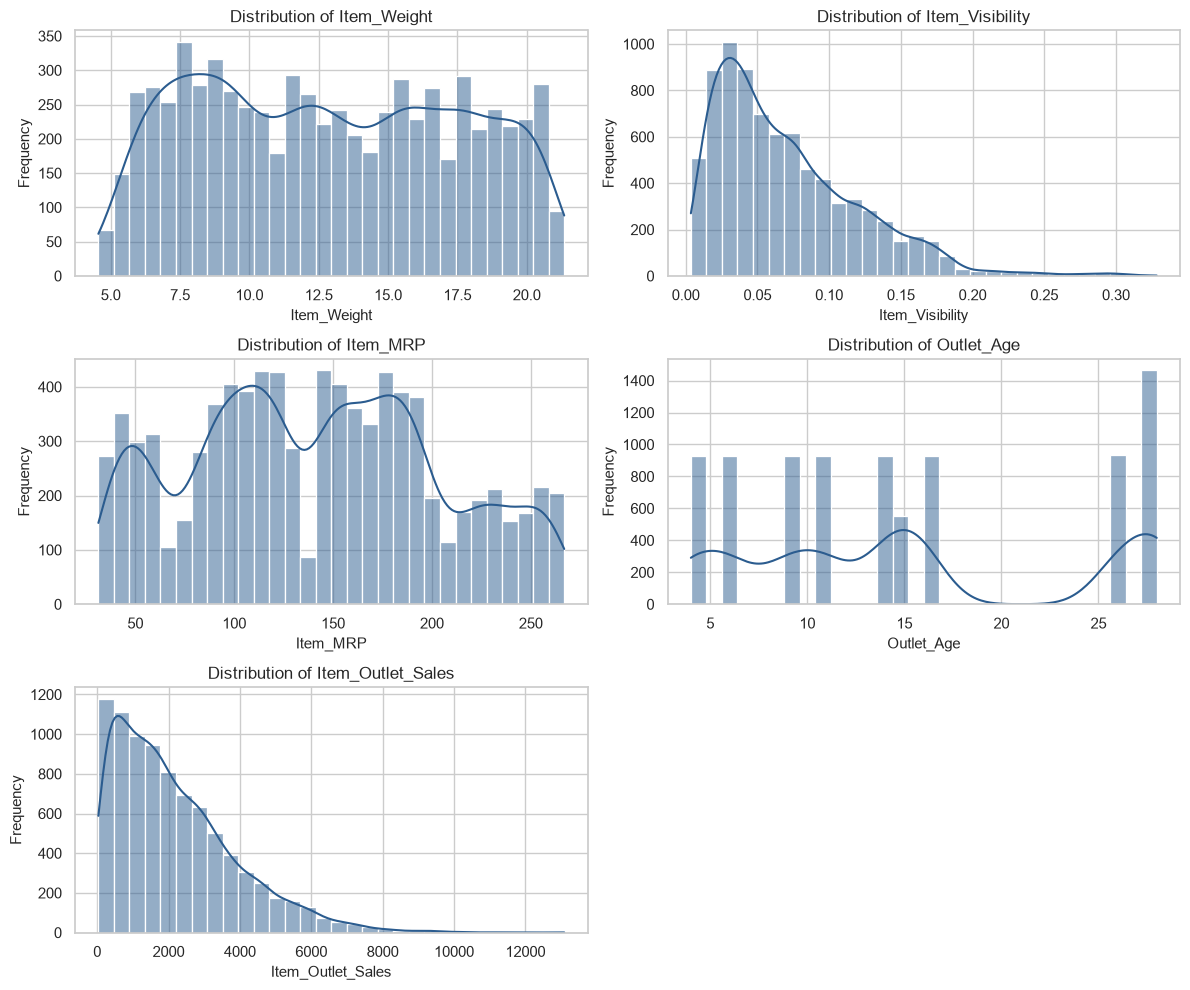

In [12]:
# Task 6: Analyze distributions of numerical variables
print("Summary Statistics for Numerical Predictors and Target:")
display(train_clean[numeric_features + [TARGET]].describe().T.round(2))

# Plot histograms with KDE for numerical variables
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

num_cols_to_plot = numeric_features + [TARGET]
for i, col in enumerate(num_cols_to_plot):
    sns.histplot(train_clean[col].dropna(), kde=True, ax=axes[i], color="#2b5c8f", bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

if len(num_cols_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Task 7: Analyze Relationship Between Predictor Variables and Sales

Analyze the relationship between key independent variables and the target variable `Item_Outlet_Sales` through scatter plots and comparative categorical plots.

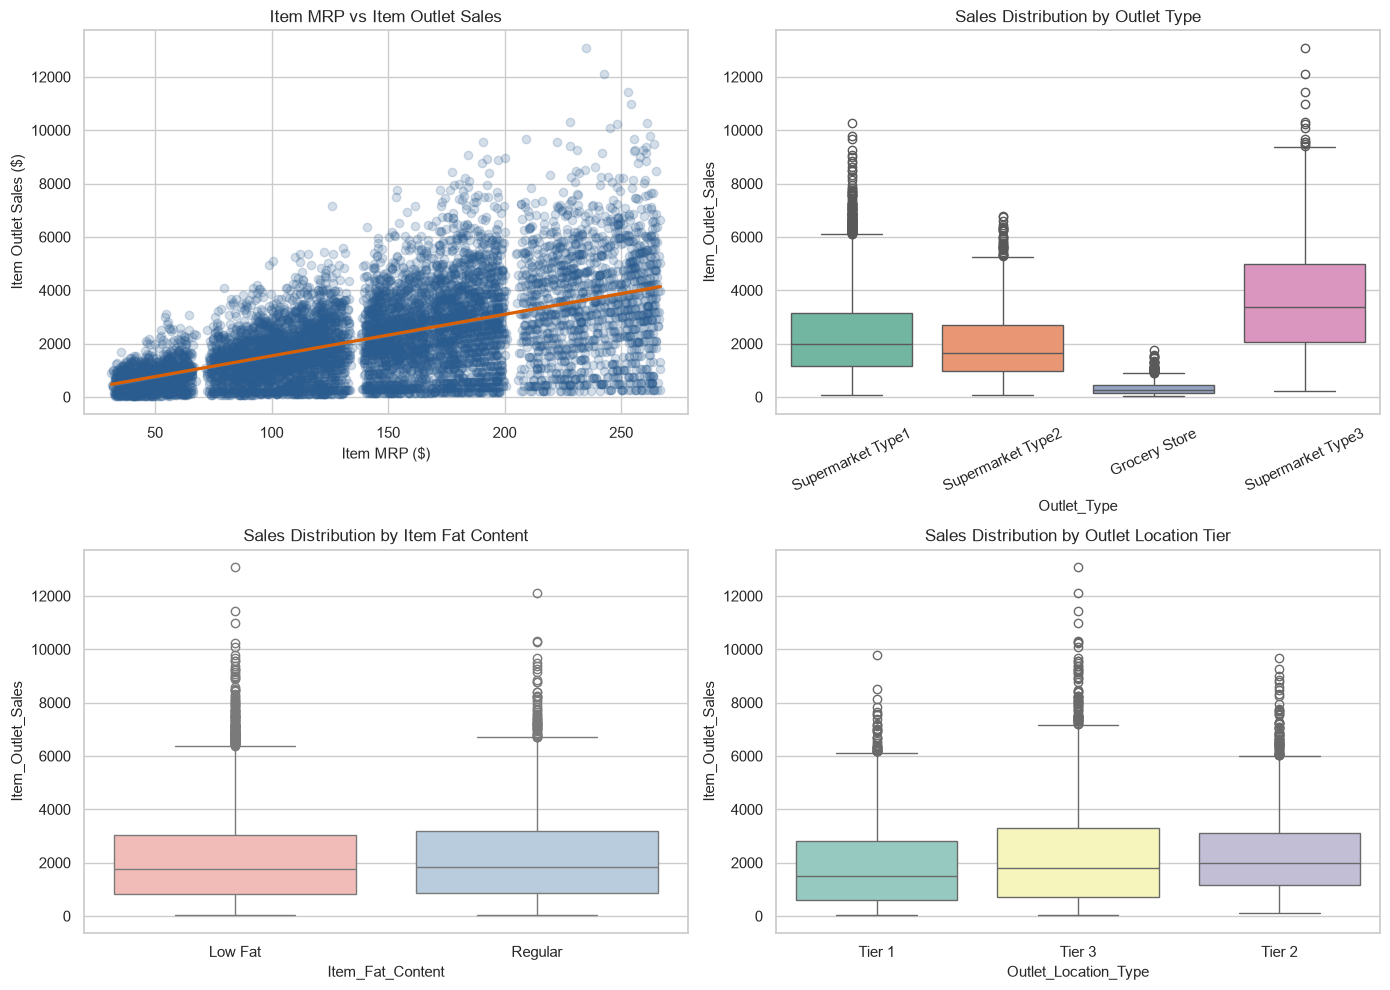


Mean Item_Outlet_Sales by Outlet Type:


,count,mean,median,std
Outlet_Type,,,,
Grocery Store,1083,339.83,257.00,260.85
Supermarket Type1,5577,2316.18,1990.74,1515.97
Supermarket Type2,928,1995.50,1655.18,1375.93
Supermarket Type3,935,3694.04,3364.95,2127.76


In [13]:
# Task 7: Relationship analysis with Item_Outlet_Sales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7.1 Item_MRP vs Item_Outlet_Sales (Scatter & Trendline)
sns.regplot(
    data=train_clean, x="Item_MRP", y=TARGET, ax=axes[0, 0],
    scatter_kws={"alpha": 0.2, "color": "#2b5c8f"}, line_kws={"color": "#d95f02"}
)
axes[0, 0].set_title("Item MRP vs Item Outlet Sales")
axes[0, 0].set_xlabel("Item MRP ($)")
axes[0, 0].set_ylabel("Item Outlet Sales ($)")

# 7.2 Outlet_Type vs Item_Outlet_Sales (Boxplot)
sns.boxplot(data=train_clean, x="Outlet_Type", y=TARGET, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Sales Distribution by Outlet Type")
axes[0, 1].tick_params(axis='x', rotation=25)

# 7.3 Item_Fat_Content vs Item_Outlet_Sales (Boxplot)
sns.boxplot(data=train_clean, x="Item_Fat_Content", y=TARGET, ax=axes[1, 0], palette="Pastel1")
axes[1, 0].set_title("Sales Distribution by Item Fat Content")

# 7.4 Outlet_Location_Type vs Item_Outlet_Sales (Boxplot)
sns.boxplot(data=train_clean, x="Outlet_Location_Type", y=TARGET, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Sales Distribution by Outlet Location Tier")

plt.tight_layout()
plt.show()

# Print mean sales by Outlet_Type for quantitative reference
print("\nMean Item_Outlet_Sales by Outlet Type:")
display(train_clean.groupby("Outlet_Type")[TARGET].agg(["count", "mean", "median", "std"]).round(2))

## Task 8: Correlation Matrix of Numerical Features

Visualize correlations between numerical features and the target variable using a correlation matrix heatmap.

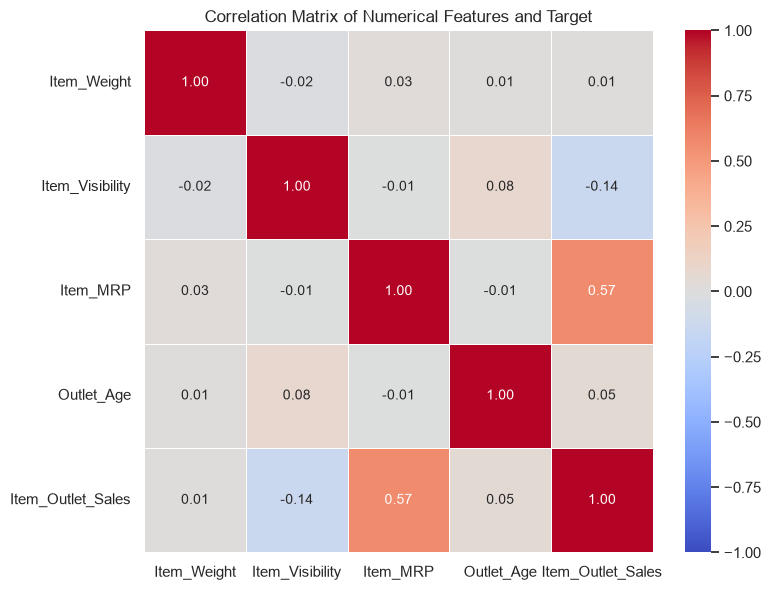

In [14]:
# Task 8: Compute and plot correlation matrix
corr_matrix = train_clean[numeric_features + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features and Target")
plt.tight_layout()
plt.show()

## Task 9: Encode Categorical Variables and Build Preprocessing Pipeline

Construct an scikit-learn `ColumnTransformer` with `SimpleImputer` and `StandardScaler` for numerical features, and `SimpleImputer` and `OneHotEncoder(handle_unknown='ignore')` for categorical features within an end-to-end `Pipeline`.

In [15]:
# Task 9: Define preprocessing transformers and ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("ColumnTransformer successfully configured.")

ColumnTransformer successfully configured.


## Task 10 & 11: Train-Test Split and Target Definition

Define independent variables ($X$) and target variable ($y$), and partition the labeled training dataset into training (80%) and validation (20%) sets.

In [16]:
# Task 10 & 11: Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"X_valid shape: {X_valid.shape[0]:,} rows, {X_valid.shape[1]} columns")
print(f"y_train shape: {y_train.shape[0]:,} target values")
print(f"y_valid shape: {y_valid.shape[0]:,} target values")

X_train shape: 6,818 rows, 10 columns
X_valid shape: 1,705 rows, 10 columns
y_train shape: 6,818 target values
y_valid shape: 1,705 target values


## Task 12: Build and Train Validation Linear Regression Model

Build a Linear Regression model using the training split (`X_train`, `y_train`) via the scikit-learn preprocessing and regression pipeline.


In [17]:
# Task 12: Build and fit the validation Linear Regression pipeline
validation_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Fit pipeline strictly on training split to prevent data leakage
validation_model_pipeline.fit(X_train, y_train)
print("Validation Linear Regression pipeline successfully fitted on X_train, y_train.")


Validation Linear Regression pipeline successfully fitted on X_train, y_train.


## Task 13 & 14: Predict Sales and Evaluate Performance on Validation Set

Use the trained validation model to predict sales for the validation set (`X_valid`) and evaluate model performance using $R^2$ Score, MAE, MSE, and RMSE. Diagnose linear regression assumptions with concise residual analysis.


In [18]:
# Task 14: Evaluate model performance on validation set
y_valid_pred = validation_model_pipeline.predict(X_valid)

r2 = r2_score(y_valid, y_valid_pred)
mae = mean_absolute_error(y_valid, y_valid_pred)
mse = mean_squared_error(y_valid, y_valid_pred)
rmse = np.sqrt(mse)

metrics_df = pd.DataFrame({
    "Evaluation Metric": ["R² Score", "MAE", "MSE", "RMSE"],
    "Validation Value": [r2, mae, mse, rmse]
})
metrics_df["Validation Value"] = metrics_df["Validation Value"].round(4)

print("Validation Model Performance:")
display(metrics_df)


Validation Model Performance:


,Evaluation Metric,Validation Value
0,R² Score,5.798000e-01
1,MAE,7.911648e+02
2,MSE,1.142014e+06
3,RMSE,1.068650e+03


### Concise Residual Analysis

Examine the validation model residuals ($e_i = y_{\text{valid}} - \hat{y}_{\text{valid}}$) to inspect error patterns.

*Note: Residual diagnostics provide evidence about the error pattern, but they do not by themselves prove that all Linear Regression assumptions (such as normality, homoscedasticity, or independence) are satisfied.*


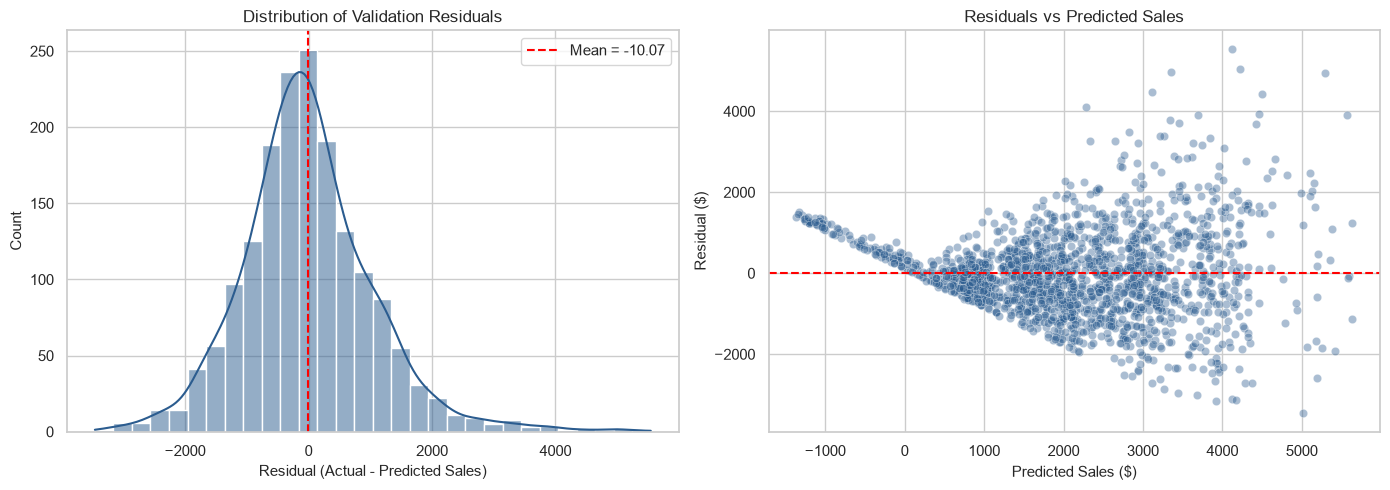

Mean Validation Residual: -10.0735
Residual diagnostics provide evidence about the error pattern, but they do not by themselves prove that all Linear Regression assumptions are satisfied.


In [19]:
# Residual Analysis Plots
residuals = y_valid - y_valid_pred
mean_residual = residuals.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual Histogram / KDE
sns.histplot(residuals, kde=True, ax=axes[0], color="#2b5c8f", bins=30)
axes[0].axvline(mean_residual, color="red", linestyle="--", label=f"Mean = {mean_residual:.2f}")
axes[0].set_title("Distribution of Validation Residuals")
axes[0].set_xlabel("Residual (Actual - Predicted Sales)")
axes[0].legend()

# Residuals vs Predicted Sales
sns.scatterplot(x=y_valid_pred, y=residuals, ax=axes[1], alpha=0.4, color="#2b5c8f")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs Predicted Sales")
axes[1].set_xlabel("Predicted Sales ($)")
axes[1].set_ylabel("Residual ($)")

plt.tight_layout()
plt.show()

print(f"Mean Validation Residual: {mean_residual:.4f}")
print("Residual diagnostics provide evidence about the error pattern, but they do not by themselves prove that all Linear Regression assumptions are satisfied.")


### Retrain Pipeline on 100% Labeled Data and Predict Official Test Dataset

Following validation evaluation, fit the final preprocessing + Linear Regression pipeline on 100% of the labeled dataset (`X`, `y`) to construct the final model. Then apply the same feature engineering/preprocessing pipeline to the official unlabeled test dataset (`test.csv`) to generate official test predictions.

*Note: The official test dataset is not used for model evaluation because it does not contain target sales values.*


In [20]:
# Retrain final model on 100% of labeled training dataset
final_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

final_model_pipeline.fit(X, y)
print("Final model pipeline retrained on 100% of labeled training data (8,523 rows).")

# Prepare test features (excluding identifiers matching X)
X_test = test_clean.drop(columns=["Item_Identifier", "Outlet_Identifier", "Outlet_Establishment_Year"], errors="ignore")

# Generate official test predictions using the final model
official_test_preds = final_model_pipeline.predict(X_test)

# Format prediction output dataframe
test_predictions_df = test_clean[["Item_Identifier", "Outlet_Identifier"]].copy()
test_predictions_df[TARGET] = official_test_preds

print("\nOfficial Test Sales Predictions (First 10 Records):")
display(test_predictions_df.head(10))

# Save predictions and export final fitted pipeline model artifact
output_csv_path = Path("bigmart_sales_predictions.csv")
test_predictions_df.to_csv(output_csv_path, index=False)

model_pkl_path = Path("bigmart_linear_regression.pkl")
joblib.dump(final_model_pipeline, model_pkl_path)

print(f"\nSuccessfully saved {len(test_predictions_df):,} official test predictions to: {output_csv_path.resolve()}")
print(f"Successfully exported final model pipeline to:             {model_pkl_path.resolve()}")


Final model pipeline retrained on 100% of labeled training data (8,523 rows).

Official Test Sales Predictions (First 10 Records):


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1787.486987
1,FDW14,OUT017,1558.723676
2,NCN55,OUT010,1881.687194
3,FDQ58,OUT017,2617.915100
4,FDY38,OUT027,5132.223775
5,FDH56,OUT046,2002.056215
6,FDL48,OUT018,593.298200
7,FDC48,OUT027,2780.519100
8,FDN33,OUT045,1507.888352
9,FDA36,OUT017,3126.423243



Successfully saved 5,681 official test predictions to: D:\AI_Training\bigmart_sales_predictions.csv
Successfully exported final model pipeline to:             D:\AI_Training\bigmart_linear_regression.pkl


## Task 15: Interpret Linear Regression Coefficients

Extract and interpret the regression coefficients of the final fitted Linear Regression model to evaluate linear associations between predictor features and target sales, holding all other included predictors constant.


In [21]:
# Task 15: Extract fitted regression coefficients from the final model
fitted_prep = final_model_pipeline.named_steps["preprocessor"]
fitted_reg = final_model_pipeline.named_steps["regressor"]

feature_names = fitted_prep.get_feature_names_out()
coefficients = fitted_reg.coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Magnitude": np.abs(coefficients)
}).sort_values("Absolute_Magnitude", ascending=False).reset_index(drop=True)

print("Linear Regression Coefficients Table (Top 15 Features by Absolute Magnitude):")
display(coef_table.head(15).round(4))


Linear Regression Coefficients Table (Top 15 Features by Absolute Magnitude):


,Feature,Coefficient,Absolute_Magnitude
0,cat__Outlet_Type_Supermarket Type3,3883.9921,3883.9921
1,cat__Outlet_Type_Supermarket Type1,1452.2145,1452.2145
2,cat__Outlet_Type_Supermarket Type2,1186.1701,1186.1701
3,num__Item_MRP,969.6636,969.6636
4,cat__Outlet_Size_Medium,-932.4326,932.4326
5,cat__Outlet_Size_Small,-855.3007,855.3007
6,cat__Outlet_Location_Type_Tier 3,-466.4443,466.4443
7,num__Outlet_Age,-338.6253,338.6253
8,cat__Outlet_Location_Type_Tier 2,-232.4548,232.4548
9,cat__Item_Type_Seafood,187.8584,187.8584


### Coefficient Interpretation Principles
- **Regression Coefficients vs. Feature Importance**: Model parameters in Linear Regression are **regression coefficients (weights)** representing estimated linear slope coefficients, not tree-based "feature importance" scores.
- **`Item_MRP` Role**: `Item_MRP` is an important numerical predictor in the fitted Linear Regression model.
- **Standardized Predictors**: Numerical features were scaled with `StandardScaler`. Thus, each numerical coefficient represents the expected change in `Item_Outlet_Sales` (in dollars) per one standard deviation change in that feature, holding all other included features constant.
- **One-Hot Categorical Features**: Dummy-encoded categorical variables represent the expected differential in sales relative to the omitted baseline category for that categorical feature.
- **Associational Phrasing**: Coefficients describe linear associations observed in historical data; they do not imply direct causal effects.


## Task 16: Key Insights and Summary

Summarize the core findings, model metrics, numerical insights, and conclusions obtained from the analysis.

In [22]:
# Task 16: Generate exact numerical summaries for business reporting
overall_mean_sales = train_clean[TARGET].mean()
mrp_min, mrp_max = train_clean["Item_MRP"].min(), train_clean["Item_MRP"].max()
sm3_sales = train_clean[train_clean["Outlet_Type"] == "Supermarket Type3"][TARGET].mean()
grocery_sales = train_clean[train_clean["Outlet_Type"] == "Grocery Store"][TARGET].mean()

print(f"Overall Average Sales:           ${overall_mean_sales:,.2f}")
print(f"Item MRP Range:                  ${mrp_min:.2f} to ${mrp_max:.2f}")
print(f"Supermarket Type3 Average Sales: ${sm3_sales:,.2f}")
print(f"Grocery Store Average Sales:     ${grocery_sales:,.2f}")
print(f"Validation R² Score:             {r2:.4f} ({r2 * 100:.2f}% variance explained)")
print(f"Validation MAE:                  ${mae:,.2f}")
print(f"Validation RMSE:                 ${rmse:,.2f}")


Overall Average Sales:           $2,181.29
Item MRP Range:                  $31.29 to $266.89
Supermarket Type3 Average Sales: $3,694.04
Grocery Store Average Sales:     $339.83
Validation R² Score:             0.5798 (57.98% variance explained)
Validation MAE:                  $791.16
Validation RMSE:                 $1,068.65


### Summary of Results and Key Insights

### Q&A
- **Q1: Which features display notable linear associations with product sales?**  
  **A1:** `Item_MRP` is an important numerical predictor in the fitted Linear Regression model ($r = 0.57$), exhibiting a positive linear association with product sales. `Outlet_Type_Supermarket Type3` is also associated with higher predicted sales relative to the baseline store category.
- **Q2: How does outlet store type relate to average store sales performance?**  
  **A2:** Outlet type shows substantial sales variance in historical data. `Supermarket Type3` achieves the highest mean sales of **$3,694.04**, whereas `Grocery Store` records the lowest mean sales of **$339.83**.

### Data Analysis Key Findings
- **Predictive Baseline**: The model achieved an R² of **0.5798** on the unseen validation dataset, indicating that the linear regression pipeline explains approximately **57.98%** of the variance in product sales.
- **Validation Errors**: The validation MAE was **$791.16** and the validation RMSE was **$1,068.65**. These metrics quantify average prediction magnitude errors on unseen validation observations.
- **Item Pricing Association**: Higher `Item_MRP` values are linearly associated with higher dollar revenue per product observation when holding other included predictors constant.
- **Preprocessing Safeguards**: Inconsistent `Item_Fat_Content` labels (`LF`, `low fat`, `reg`) were standardized to `Low Fat` and `Regular`. Missing/zero visibility values were handled programmatically through the pipeline without data leakage.

### Business Insights & Conclusions
- **Model Architecture & Scope**: This study establishes an interpretable Linear Regression baseline. Validation metrics are calculated strictly on unseen validation data (`X_valid`, `y_valid`).
- **Interpretation & Limitations**: While the model provides an interpretable baseline, it has limitations. Prediction errors are larger for some high-sales observations, reflecting potential non-linear relationships or unobserved outlet/item dynamics.
- **Official Test Predictions**: The official test predictions are generated only after fitting the final model on 100% of the labeled training data (`X`, `y`) and applying the identical feature engineering/preprocessing pipeline.
- **Future Reference**: Subsequent modeling iterations could explore non-linear or regularized regression approaches to better handle complex non-linear interactions while maintaining rigorous validation splitting.
